# MLP Function Approximation: 1D Consolidation Settlement

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/00-mlp-dtree/00c-mlp-function-approximation-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/00-mlp-dtree/00c-mlp-function-approximation.ipynb)

In [1]:
!pip install torch numpy matplotlib --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /Users/krishna/courses/CE397-Scientific-MachineLearning/utp-sciml/env/bin/python -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Problem: 1D Consolidation Settlement

**Goal:** Predict settlement vs time from sparse field measurements.

Consolidation theory (Terzaghi):
$$S(t) = S_{\text{final}}(1 - e^{-\alpha t})$$

- $S_{\text{final}} = 100$ mm (ultimate settlement)
- $\alpha = 0.5$ /year (consolidation coefficient)
- Sparse field data: 10 measurements over 10 years

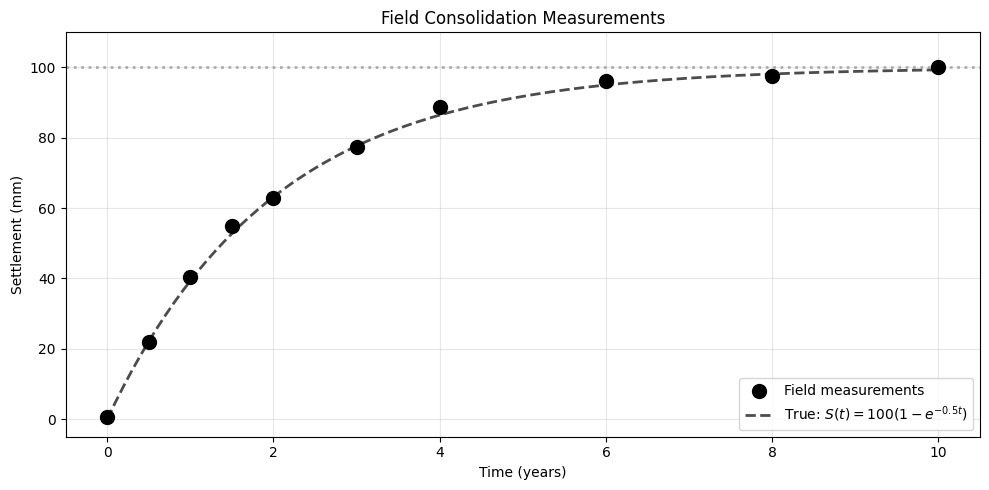

Measurements: 10 points
Challenge: Predict settlement at any time in [0, 10] years


In [3]:
# True parameters
S_final = 100.0
alpha = 0.5

# Field measurements (sparse)
t_field = np.array([0, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 10])
S_true = S_final * (1 - np.exp(-alpha * t_field))
S_measured = S_true + np.random.normal(0, 1.5, len(t_field))
S_measured = np.maximum(S_measured, 0)

# Dense evaluation grid
t_dense = np.linspace(0, 10, 200)
S_dense = S_final * (1 - np.exp(-alpha * t_dense))

# Plot field data
plt.figure(figsize=(10, 5))
plt.scatter(t_field, S_measured, s=100, color='black', label='Field measurements', zorder=5)
plt.plot(t_dense, S_dense, 'k--', linewidth=2, label='True: $S(t) = 100(1-e^{-0.5t})$', alpha=0.7)
plt.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.6)
plt.xlabel('Time (years)')
plt.ylabel('Settlement (mm)')
plt.title('Field Consolidation Measurements')
plt.legend()
plt.xlim(-0.5, 10.5)
plt.ylim(-5, 110)
plt.tight_layout()
plt.show()

print(f"Measurements: {len(t_field)} points")
print(f"Challenge: Predict settlement at any time in [0, 10] years")

## Part 1: Single Neuron (Perceptron)

$$\hat{S} = w \cdot t + b$$

Can a linear model fit consolidation?

In [4]:
# Convert to tensors
t_train = torch.FloatTensor(t_field.reshape(-1, 1))
S_train = torch.FloatTensor(S_measured.reshape(-1, 1))
t_eval = torch.FloatTensor(t_dense.reshape(-1, 1))

# Linear model
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    
    def forward(self, t):
        return self.linear(t)

model_linear = LinearModel()
optimizer = optim.Adam(model_linear.parameters(), lr=0.1)
criterion = nn.MSELoss()

losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    S_pred = model_linear(t_train)
    loss = criterion(S_pred, S_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Evaluate
with torch.no_grad():
    S_pred_linear = model_linear(t_eval).numpy()

print(f"Final loss: {losses[-1]:.2f}")
print(f"Model: S = {model_linear.linear.weight.item():.2f}*t + {model_linear.linear.bias.item():.2f}")

Final loss: 286.21
Model: S = 9.16*t + 30.09


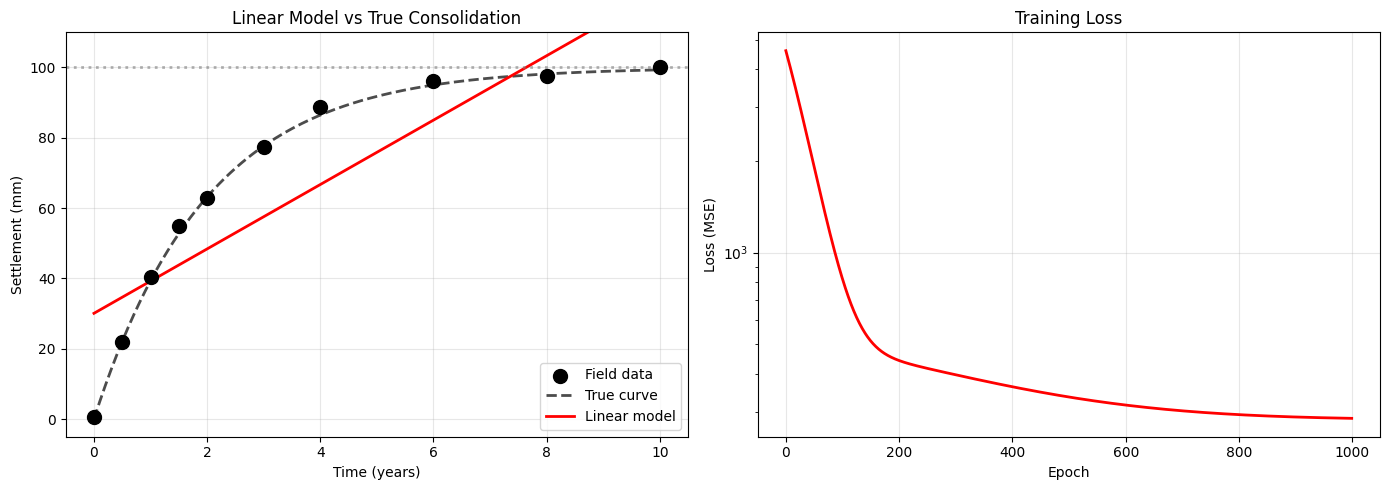


⚠️ Linear model cannot capture exponential decay!


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predictions
ax1.scatter(t_field, S_measured, s=100, color='black', label='Field data', zorder=5)
ax1.plot(t_dense, S_dense, 'k--', linewidth=2, label='True curve', alpha=0.7)
ax1.plot(t_dense, S_pred_linear, 'r-', linewidth=2, label='Linear model')
ax1.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Settlement (mm)')
ax1.set_title('Linear Model vs True Consolidation')
ax1.legend()
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-5, 110)

# Loss
ax2.plot(losses, 'r-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Training Loss')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n⚠️ Linear model cannot capture exponential decay!")

## Part 2: Adding Nonlinearity

Single layer with activation:
$$\hat{S} = w_2 \cdot \sigma(w_1 \cdot t + b_1) + b_2$$

where $\sigma = \tanh$

In [6]:
class SingleLayerNN(nn.Module):
    def __init__(self, n_hidden=10):
        super().__init__()
        self.fc1 = nn.Linear(1, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 1)
    
    def forward(self, t):
        t = torch.tanh(self.fc1(t))
        return self.fc2(t)

model_tanh = SingleLayerNN(n_hidden=10)
optimizer = optim.Adam(model_tanh.parameters(), lr=0.01)

losses_tanh = []
for epoch in range(2000):
    optimizer.zero_grad()
    S_pred = model_tanh(t_train)
    loss = criterion(S_pred, S_train)
    loss.backward()
    optimizer.step()
    losses_tanh.append(loss.item())

with torch.no_grad():
    S_pred_tanh = model_tanh(t_eval).numpy()

print(f"Final loss: {losses_tanh[-1]:.4f}")

Final loss: 5.3983


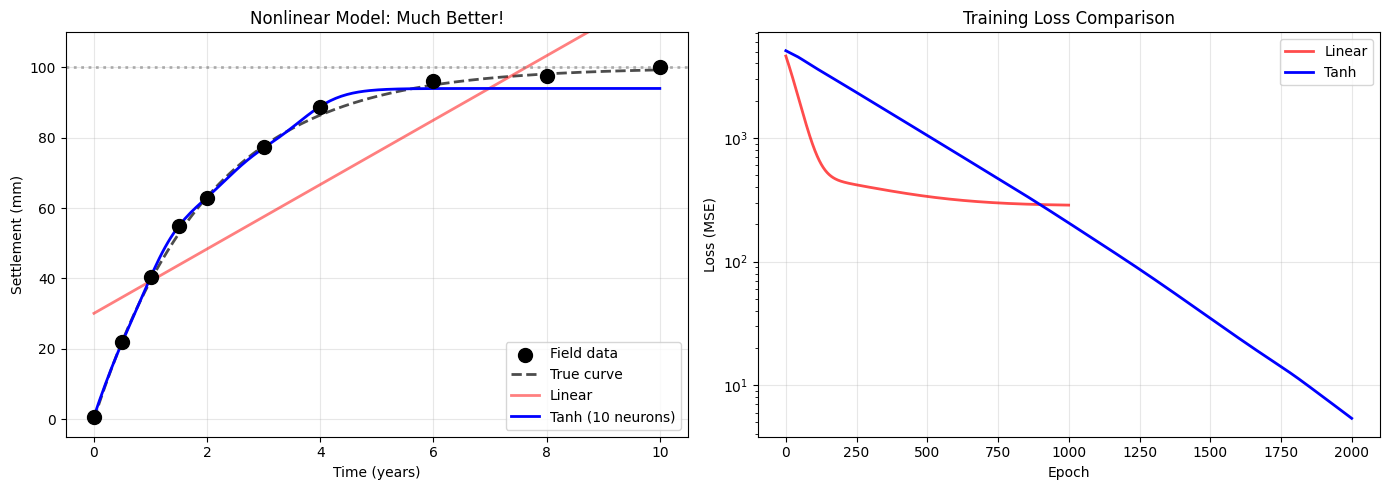

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predictions
ax1.scatter(t_field, S_measured, s=100, color='black', label='Field data', zorder=5)
ax1.plot(t_dense, S_dense, 'k--', linewidth=2, label='True curve', alpha=0.7)
ax1.plot(t_dense, S_pred_linear, 'r-', linewidth=2, label='Linear', alpha=0.5)
ax1.plot(t_dense, S_pred_tanh, 'b-', linewidth=2, label='Tanh (10 neurons)')
ax1.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Settlement (mm)')
ax1.set_title('Nonlinear Model: Much Better!')
ax1.legend()
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-5, 110)

# Loss comparison
ax2.plot(losses, 'r-', linewidth=2, label='Linear', alpha=0.7)
ax2.plot(losses_tanh, 'b-', linewidth=2, label='Tanh')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Training Loss Comparison')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

## Part 3: Effect of Network Width

How many neurons do we need?

In [8]:
def train_model(n_hidden, epochs=2000):
    model = SingleLayerNN(n_hidden=n_hidden)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_pred = model(t_train)
        loss = criterion(S_pred, S_train)
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        S_pred = model(t_eval).numpy()
    
    return S_pred, loss.item()

widths = [1, 5, 10, 20, 50]
results = {}

for w in widths:
    print(f"Training with {w} neurons...")
    S_pred, final_loss = train_model(w)
    results[w] = {'pred': S_pred, 'loss': final_loss}
    print(f"  Final loss: {final_loss:.4f}")

Training with 1 neurons...
  Final loss: 1691.7102
Training with 5 neurons...
  Final loss: 146.0258
Training with 10 neurons...
  Final loss: 6.5273
Training with 20 neurons...
  Final loss: 0.2930
Training with 50 neurons...
  Final loss: 0.1969


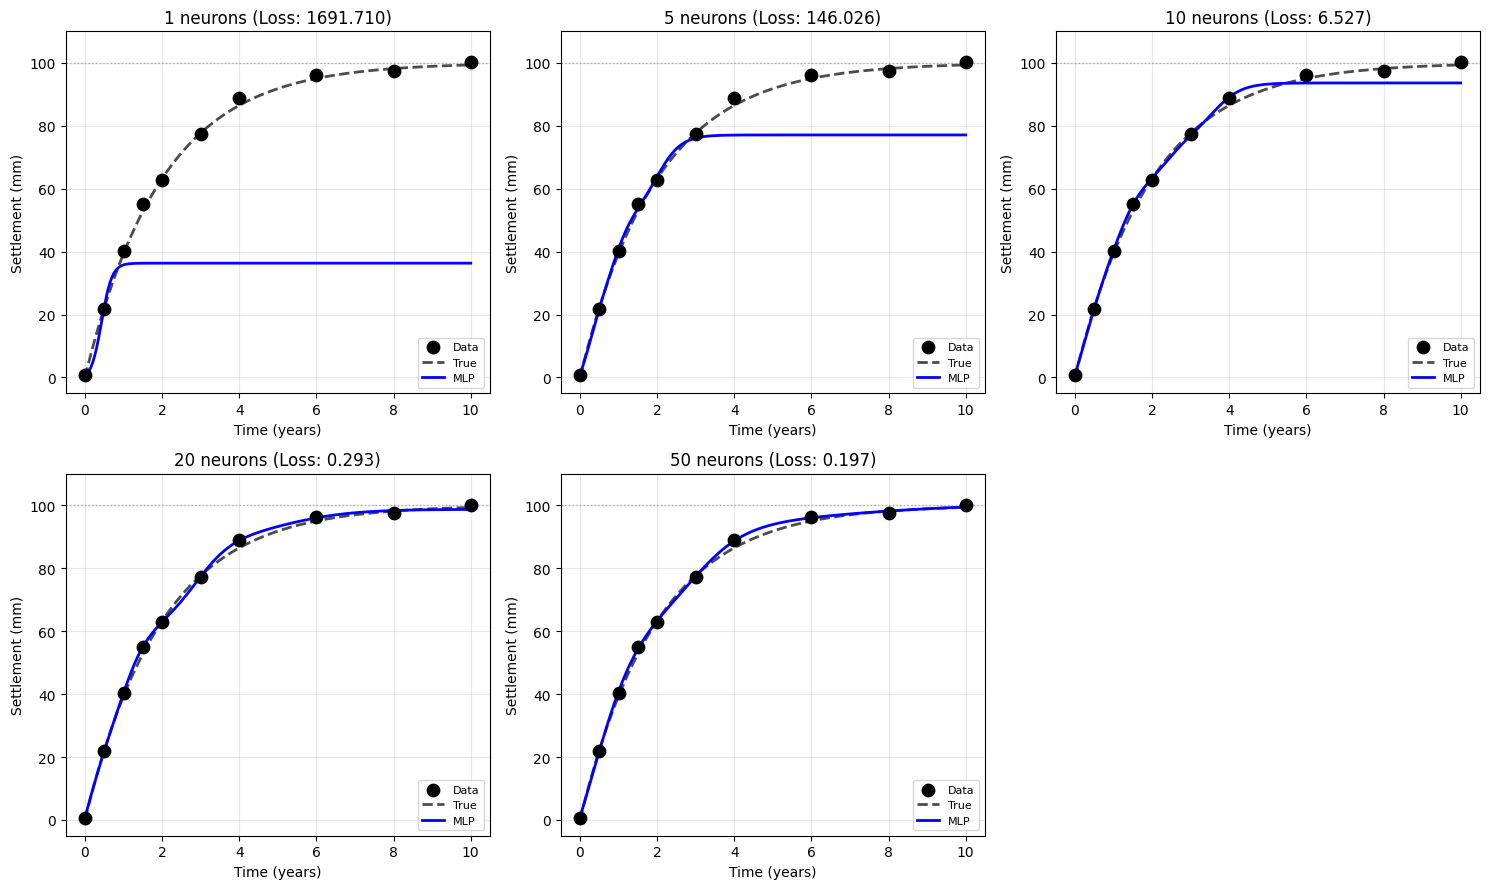


Observation: 10-20 neurons sufficient for smooth approximation


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, w in enumerate(widths):
    ax = axes[idx]
    ax.scatter(t_field, S_measured, s=80, color='black', label='Data', zorder=5)
    ax.plot(t_dense, S_dense, 'k--', linewidth=2, label='True', alpha=0.7)
    ax.plot(t_dense, results[w]['pred'], 'b-', linewidth=2, label='MLP')
    ax.axhline(S_final, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title(f'{w} neurons (Loss: {results[w]["loss"]:.3f})')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Settlement (mm)')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-5, 110)

# Remove extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("\nObservation: 10-20 neurons sufficient for smooth approximation")

## Part 4: Deep Network (2 Hidden Layers)

$$\hat{S} = w_3 \cdot \sigma(w_2 \cdot \sigma(w_1 \cdot t + b_1) + b_2) + b_3$$

In [10]:
class DeepNN(nn.Module):
    def __init__(self, n_hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(1, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, 1)
    
    def forward(self, t):
        t = torch.tanh(self.fc1(t))
        t = torch.tanh(self.fc2(t))
        return self.fc3(t)

model_deep = DeepNN(n_hidden=16)
optimizer = optim.Adam(model_deep.parameters(), lr=0.01)

losses_deep = []
for epoch in range(2000):
    optimizer.zero_grad()
    S_pred = model_deep(t_train)
    loss = criterion(S_pred, S_train)
    loss.backward()
    optimizer.step()
    losses_deep.append(loss.item())

with torch.no_grad():
    S_pred_deep = model_deep(t_eval).numpy()

print(f"Deep network final loss: {losses_deep[-1]:.4f}")
print(f"Parameters: {sum(p.numel() for p in model_deep.parameters())}")

Deep network final loss: 0.8362
Parameters: 321


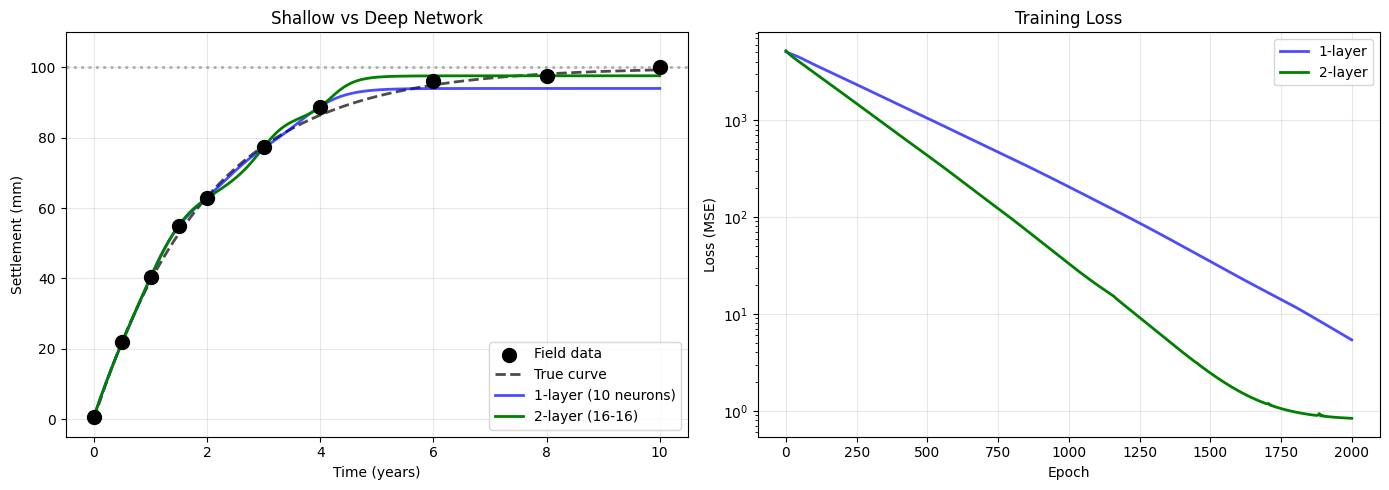

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predictions
ax1.scatter(t_field, S_measured, s=100, color='black', label='Field data', zorder=5)
ax1.plot(t_dense, S_dense, 'k--', linewidth=2, label='True curve', alpha=0.7)
ax1.plot(t_dense, S_pred_tanh, 'b-', linewidth=2, label='1-layer (10 neurons)', alpha=0.7)
ax1.plot(t_dense, S_pred_deep, 'g-', linewidth=2, label='2-layer (16-16)')
ax1.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Settlement (mm)')
ax1.set_title('Shallow vs Deep Network')
ax1.legend()
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-5, 110)

# Loss
ax2.plot(losses_tanh, 'b-', linewidth=2, label='1-layer', alpha=0.7)
ax2.plot(losses_deep, 'g-', linewidth=2, label='2-layer')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Training Loss')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

## Part 5: Optimizer Comparison

SGD vs Momentum vs Adam

In [12]:
def train_optimizer(opt_name, lr=0.01, epochs=2000):
    model = DeepNN(n_hidden=16)
    
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif opt_name == 'Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_pred = model(t_train)
        loss = criterion(S_pred, S_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    with torch.no_grad():
        S_pred = model(t_eval).numpy()
    
    return losses, S_pred

optimizers = ['SGD', 'Momentum', 'Adam']
opt_results = {}

for opt in optimizers:
    print(f"Training with {opt}...")
    losses, S_pred = train_optimizer(opt)
    opt_results[opt] = {'losses': losses, 'pred': S_pred}
    print(f"  Final loss: {losses[-1]:.4f}")

Training with SGD...
  Final loss: 0.2308
Training with Momentum...
  Final loss: 348.8771
Training with Adam...
  Final loss: 0.8509


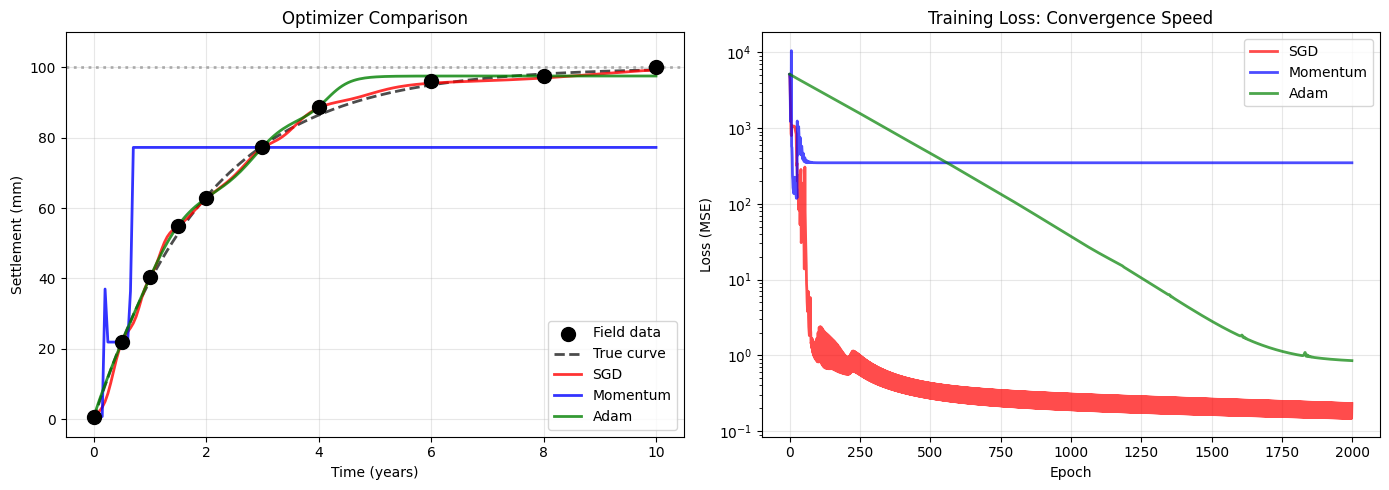


Adam converges fastest, SGD is slowest


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predictions
ax1.scatter(t_field, S_measured, s=100, color='black', label='Field data', zorder=5)
ax1.plot(t_dense, S_dense, 'k--', linewidth=2, label='True curve', alpha=0.7)
colors = {'SGD': 'red', 'Momentum': 'blue', 'Adam': 'green'}
for opt in optimizers:
    ax1.plot(t_dense, opt_results[opt]['pred'], color=colors[opt], linewidth=2, label=opt, alpha=0.8)
ax1.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Settlement (mm)')
ax1.set_title('Optimizer Comparison')
ax1.legend()
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-5, 110)

# Loss curves
for opt in optimizers:
    ax2.plot(opt_results[opt]['losses'], color=colors[opt], linewidth=2, label=opt, alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Training Loss: Convergence Speed')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nAdam converges fastest, SGD is slowest")

## Part 6: Activation Function Comparison

ReLU vs Tanh vs Sigmoid

In [14]:
class MLPActivation(nn.Module):
    def __init__(self, activation='tanh', n_hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(1, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, 1)
        
        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'sigmoid':
            self.act = nn.Sigmoid()
    
    def forward(self, t):
        t = self.act(self.fc1(t))
        t = self.act(self.fc2(t))
        return self.fc3(t)

def train_activation(activation, epochs=3000):
    model = MLPActivation(activation=activation, n_hidden=32)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        S_pred = model(t_train)
        loss = criterion(S_pred, S_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    with torch.no_grad():
        S_pred = model(t_eval).numpy()
    
    mse = np.mean((S_pred - S_dense.reshape(-1, 1))**2)
    return losses, S_pred, mse

activations = ['relu', 'tanh', 'sigmoid']
act_results = {}

for act in activations:
    print(f"Training with {act.upper()}...")
    losses, S_pred, mse = train_activation(act)
    act_results[act] = {'losses': losses, 'pred': S_pred, 'mse': mse}
    print(f"  Test MSE: {mse:.2f} mm²")

Training with RELU...
  Test MSE: 4.03 mm²
Training with TANH...
  Test MSE: 2.55 mm²
Training with SIGMOID...
  Test MSE: 3.32 mm²


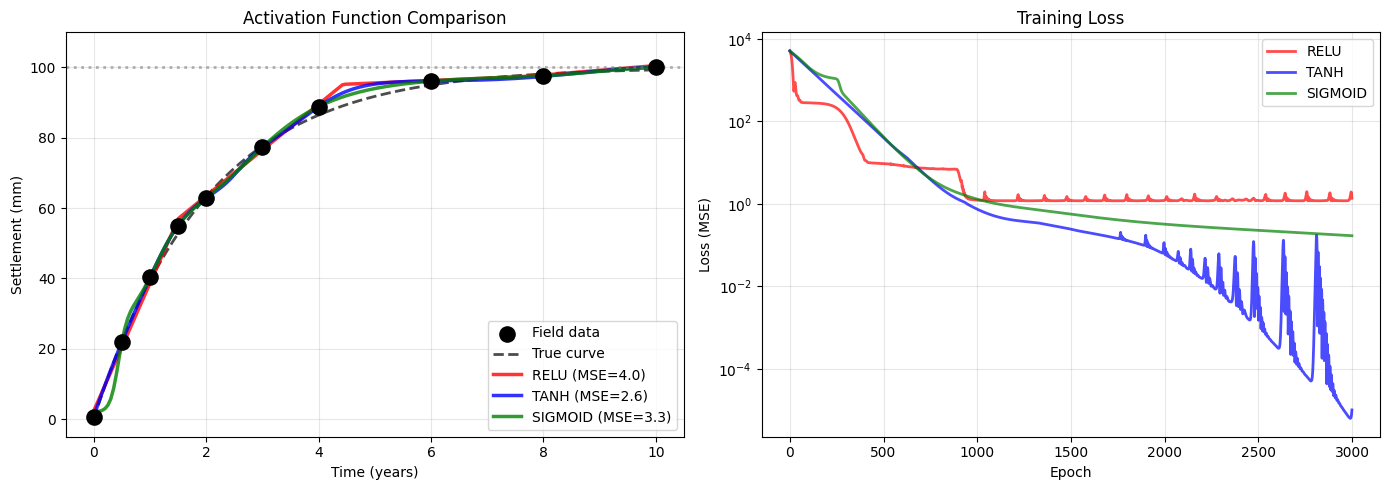

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predictions
ax1.scatter(t_field, S_measured, s=120, color='black', label='Field data', zorder=5)
ax1.plot(t_dense, S_dense, 'k--', linewidth=2, label='True curve', alpha=0.7)
colors_act = {'relu': 'red', 'tanh': 'blue', 'sigmoid': 'green'}
for act in activations:
    ax1.plot(t_dense, act_results[act]['pred'], color=colors_act[act], 
             linewidth=2.5, label=f'{act.upper()} (MSE={act_results[act]["mse"]:.1f})', alpha=0.8)
ax1.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.6)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Settlement (mm)')
ax1.set_title('Activation Function Comparison')
ax1.legend(loc='lower right')
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-5, 110)

# Loss curves
for act in activations:
    ax2.plot(act_results[act]['losses'], color=colors_act[act], linewidth=2, 
             label=f'{act.upper()}', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Training Loss')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

### Boundary Behavior Analysis

In [16]:
print(f"True settlement at t=10 years: {S_dense[-1]:.2f} mm\n")
print(f"{'Activation':<12} {'Prediction':<12} {'Error':<10}")
print("-" * 40)

for act in activations:
    pred_10 = act_results[act]['pred'][-1][0]
    error = pred_10 - S_dense[-1]
    print(f"{act.upper():<12} {pred_10:>10.2f} mm {error:>9.2f} mm")

print("\nTanh naturally saturates → best for bounded problems")

True settlement at t=10 years: 99.33 mm

Activation   Prediction   Error     
----------------------------------------
RELU             100.55 mm      1.22 mm
TANH             100.13 mm      0.81 mm
SIGMOID          100.01 mm      0.68 mm

Tanh naturally saturates → best for bounded problems


## Summary

**Key findings:**

1. **Linear models fail** for nonlinear consolidation
2. **10-20 neurons** sufficient for smooth approximation
3. **Deep networks** (2 layers) slightly better than shallow
4. **Adam** converges fastest among optimizers
5. **Tanh** best activation for bounded physical problems $(0 \leq S \leq S_{\text{final}})$

**Practical insight:** For geotechnical settlement prediction from sparse field data:
- Architecture: 2 layers, 16-32 neurons per layer
- Activation: Tanh
- Optimizer: Adam with lr=0.01
- Training: 2000-3000 epochs